In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [9]:
np.random.seed(44)
epochs = 100
learnrate = 0.01

In [10]:
def plot_points(X, y):
    class1 = X[np.argwhere(y==1)]
    class2 = X[np.argwhere(y==0)]
    plt.scatter([s[0][0] for s in class1], [s[0][1] for s in class1], s = 25, color = 'blue', edgecolor = 'k')
    plt.scatter([s[0][0] for s in class2], [s[0][1] for s in class2], s = 25, color = 'red', edgecolor = 'k')

def display(m, b, color='y--'):
    plt.xlim(-0.05,1.05)
    plt.ylim(-0.05,1.05)
    x = np.arange(-10, 10, 0.1)
    plt.plot(x, m*x+b, color)

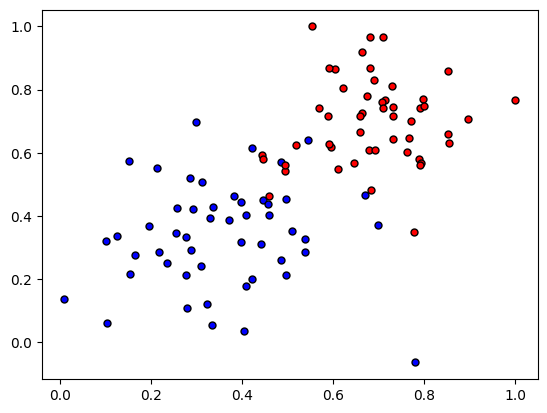

In [11]:
data = pd.read_csv('data.csv', header=None)
X = np.array(data[[0,1]])
y = np.array(data[2])
plot_points(X,y)
plt.show()

In [12]:

def sigmoid(x):
    return 1/(1+np.exp(-1*x))

def output_formula(features, weights, bias):
    return sigmoid(np.dot(features,weights)+bias)

def error_formula(y, output):
    return y-output

def update_weights(x, y, weights, bias, learnrate):
    #import pdb; pdb.set_trace()
    op = output_formula(x, weights, bias)
    weights = weights + learnrate*error_formula(y,op)*x
    bias = bias + learnrate*error_formula(y,op)
    return weights , bias

In [13]:
def train(features, targets, epochs, learnrate, graph_lines=False):
    
    errors = []
    n_records, n_features = features.shape
    last_loss = None
    weights = np.random.normal(scale=1 / n_features**.5, size=n_features)
    bias = 0
    for e in range(epochs):
        for x, y in zip(features, targets):
            output = output_formula(x, weights, bias)
            error = error_formula(y, output)
            weights, bias = update_weights(x, y, weights, bias, learnrate)
        
        out = output_formula(features, weights, bias)
        loss = np.mean(error_formula(targets, out))
        errors.append(loss)
        if e % (epochs / 10) == 0:
            print("\n========== Epoch", e,"==========")
            if last_loss and last_loss < loss:
                print("Train loss: ", loss, "  WARNING - Loss Increasing")
            else:
                print("Train loss: ", loss)
            last_loss = loss
            predictions = out > 0.5
            accuracy = np.mean(predictions == targets)
            print("Accuracy: ", accuracy)
        if graph_lines and e % (epochs / 100) == 0:
            display(-weights[0]/weights[1], -bias/weights[1])

    plt.title("Solution boundary")
    display(-weights[0]/weights[1], -bias/weights[1], 'black')

    plot_points(features, targets)
    plt.show()

    plt.title("Error Plot")
    plt.xlabel('Number of epochs')
    plt.ylabel('Error')
    plt.plot(errors)
    plt.show()


========== Epoch 0 ==========
Train loss:  -0.001143886947968229
Accuracy:  0.4

========== Epoch 10 ==========
Train loss:  0.09249974385606045   WARNING - Loss Increasing
Accuracy:  0.59

========== Epoch 20 ==========
Train loss:  0.0838920548062197
Accuracy:  0.74

========== Epoch 30 ==========
Train loss:  0.0746287423524094
Accuracy:  0.84

========== Epoch 40 ==========
Train loss:  0.06673651265319241
Accuracy:  0.86

========== Epoch 50 ==========
Train loss:  0.06009292878065777
Accuracy:  0.93

========== Epoch 60 ==========
Train loss:  0.05449867371488372
Accuracy:  0.93

========== Epoch 70 ==========
Train loss:  0.04976652980464235
Accuracy:  0.93

========== Epoch 80 ==========
Train loss:  0.04573717740639235
Accuracy:  0.94

========== Epoch 90 ==========
Train loss:  0.04228061579718505
Accuracy:  0.94


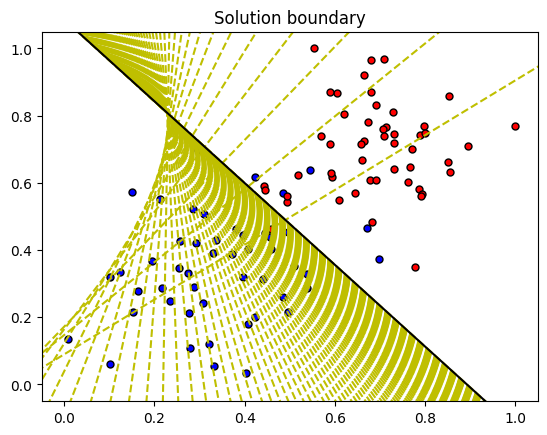

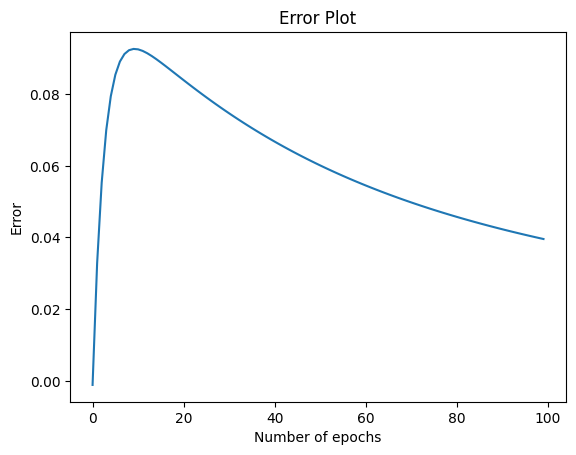

In [14]:
train(X, y, epochs, learnrate, True)